## 3. Audio Similarity Using Pretrained Embeddings
Measure the similarity between different audio clips using embeddings extracted from a pretrained audio model.

### Suggested Datasets 
[speech_commands | TensorFlow Datasets](https://www.tensorflow.org/datasets/catalog/speech_commands)

### Tasks
- Load multiple audio clips from the selected dataset.
- Extract embeddings using a pretrained audio model such as YAMNet, OpenL3, CLAP or Wav2Vec2.
- Compute pairwise similarity and distance scores.
- Visualize the relationships using a similarity heatmap and distance matrix.

### Deliverables
- A properly executed Jupyter Notebook (.ipynb).
- Similarity heatmap and distance matrix.

### Dataset used 
- used 10 sounds from [Google Speech Dataset - Kaggle](https://www.kaggle.com/datasets/yashdogra/speech-commands)


In [1]:
import librosa 
import os

PATH = "./audios/task-3"
audio = []

for filename in os.listdir(PATH):
    file_path = os.path.join(PATH, filename)
    audio.append(librosa.load(file_path, sr=16000))
# skip preprocess (the goggle speech dataset is already preprocessed)

In [2]:
# load model
import torch
import torch.nn.functional as F
from transformers import Wav2Vec2Model, Wav2Vec2Processor, Wav2Vec2Config

model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h")
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [3]:
# set to eval mode
model.eval()

Wav2Vec2Model(
  (feature_extractor): Wav2Vec2FeatureEncoder(
    (conv_layers): ModuleList(
      (0): Wav2Vec2GroupNormConvLayer(
        (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
        (activation): GELUActivation()
        (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True, bias=True)
      )
      (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
      (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
    )
  )
  (feature_projection): Wav2Vec2FeatureProjection(
    (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
    (projection): Linear(in_features=512, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): Wav2Vec2Encoder(
    (pos_conv_embed): Wav2Vec2Posit

In [4]:
def get_embedding(audio_array):
    inputs = processor(audio_array, sampling_rate=16000, return_tensors="pt", padding=True)
    with torch.no_grad():
        # Pass data through the transformer backbone
        outputs = model(**inputs)
        hidden_states = outputs.last_hidden_state
        global_embedding = torch.mean(hidden_states, dim=1)
        
    return global_embedding

In [5]:
embeddings = []

for item in audio:
    embeddings.append(get_embedding(item[0]))

In [6]:
import numpy as np

num_embeddings = len(embeddings)

similarity_matrix = np.zeros((num_embeddings, num_embeddings))
distance_matrix = np.zeros((num_embeddings, num_embeddings))

for i, embedding1 in enumerate(embeddings):
    for j, embedding2 in enumerate(embeddings):
        distance = F.pairwise_distance(embedding1, embedding2)
        distance_matrix[i, j] = distance.item()
        similarity_matrix[i, j] = 1 / (1 + distance.item())

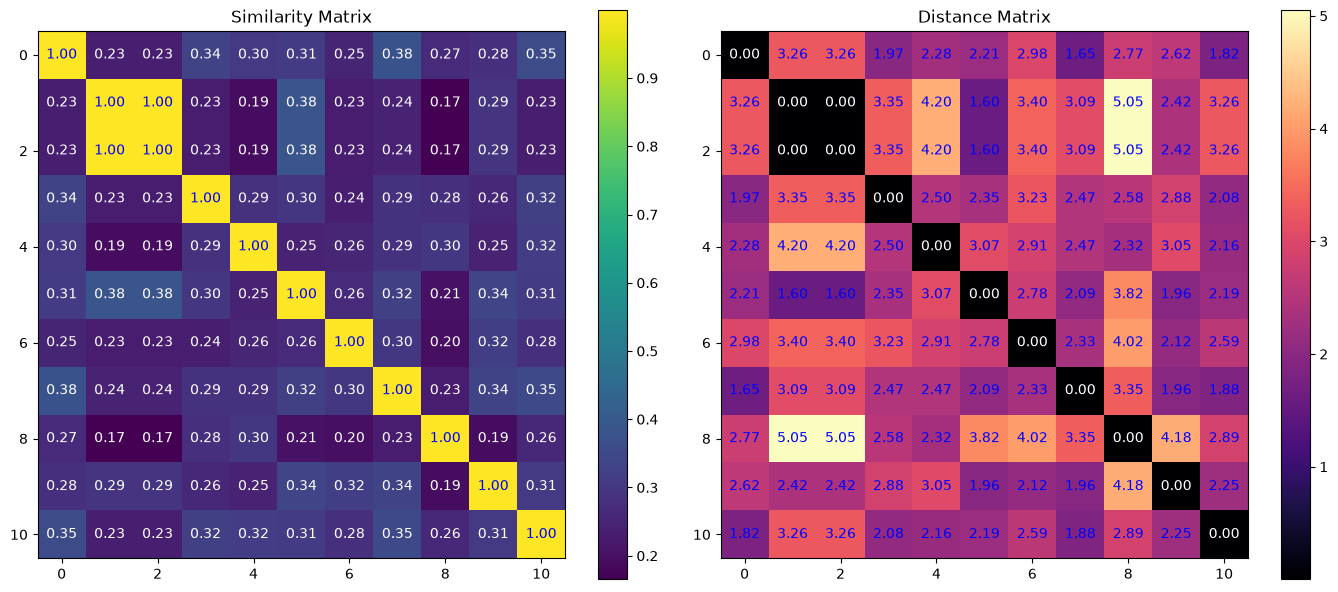

In [9]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im1 = axes[0].imshow(similarity_matrix, cmap="viridis")
axes[0].set_title("Similarity Matrix")
fig.colorbar(im1, ax=axes[0])  # Adds the color scale bar

# Add text annotations manually
for i in range(len(similarity_matrix)):
    for j in range(len(similarity_matrix[i])):
        axes[0].text(j, i, f"{similarity_matrix[i, j]:.2f}", 
                     ha="center", va="center", color="w" if similarity_matrix[i, j] < 0.5 else "b")

im2 = axes[1].imshow(distance_matrix, cmap="magma")
axes[1].set_title("Distance Matrix")
fig.colorbar(im2, ax=axes[1])  # Adds the color scale bar

# Add text annotations manually
for i in range(len(distance_matrix)):
    for j in range(len(distance_matrix[i])):
        axes[1].text(j, i, f"{distance_matrix[i, j]:.2f}", 
                     ha="center", va="center", color="w" if distance_matrix[i, j] < 0.5 else "b")

plt.tight_layout()
plt.show()
